# SVD

As on slides, SVD of matrix $A$ is: 

$A = UDV^T$

In [1]:
import numpy as np
import torch

In [10]:
A = np.array([[-1, 2, 4], [3, -2, 5], [5, 7, 7]])
A

array([[-1,  2,  4],
       [ 3, -2,  5],
       [ 5,  7,  7]])

In [11]:
u , d , vt = np.linalg.svd(A)

In [12]:
print("U is : ",u)
print("********************")
print("d is : ",d)
print("********************")
print("VT is : ",vt)

U is :  [[ 0.29443911 -0.03005485 -0.95519753]
 [ 0.3277598   0.94205995  0.0713903 ]
 [ 0.89770771 -0.33409544  0.28723007]]
********************
d is :  [12.17700693  4.98177583  2.98369097]
********************
VT is :  [[ 0.42517663  0.51057806  0.74735191]
 [ 0.23801903 -0.85971305  0.45192965]
 [ 0.87325355 -0.01426595 -0.4870572 ]]


In [14]:
np.diag(d)

array([[12.17700693,  0.        ,  0.        ],
       [ 0.        ,  4.98177583,  0.        ],
       [ 0.        ,  0.        ,  2.98369097]])

In [ ]:
# D = np.concatenate((np.diag(d), [[0, 0, 0]]), axis=0)
# D

array([[12.17700693,  0.        ,  0.        ],
       [ 0.        ,  4.98177583,  0.        ],
       [ 0.        ,  0.        ,  2.98369097],
       [ 0.        ,  0.        ,  0.        ]])

In [20]:
np.dot(u, np.dot(np.diag(d), vt))

array([[-1.,  2.,  4.],
       [ 3., -2.,  5.],
       [ 5.,  7.,  7.]])

## SVD Picture

In [22]:
from PIL import Image
import matplotlib.pyplot as plt

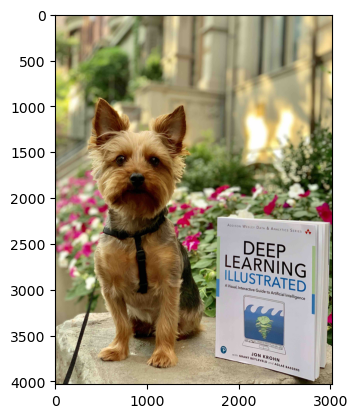

In [23]:
img = Image.open('/home/hamid/Downloads/firefox/oboe-with-book.jpg')
_ = plt.imshow(img)

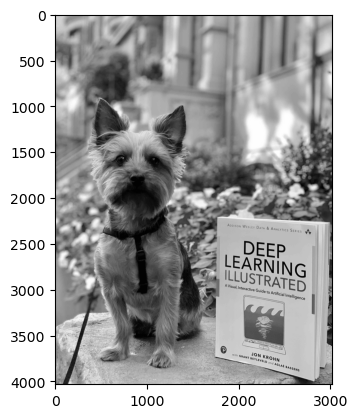

In [24]:
imggray = img.convert('LA')
_ = plt.imshow(imggray)

/tmp/ipykernel_12133/944952042.py:1: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  imgmat = np.array(list(imggray.getdata(band=0)), float)


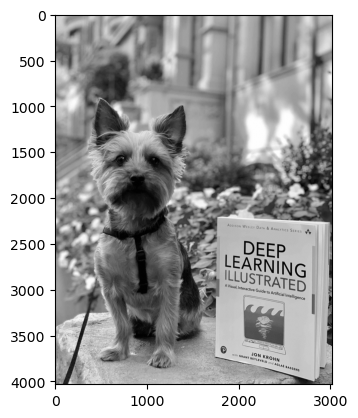

In [25]:
imgmat = np.array(list(imggray.getdata(band=0)), float)
imgmat.shape = (imggray.size[1], imggray.size[0])
imgmat = np.matrix(imgmat)
_ = plt.imshow(imgmat, cmap='gray')

In [26]:
imgmat

matrix([[209., 209., 209., ..., 212., 212., 212.],
        [209., 209., 209., ..., 212., 212., 212.],
        [209., 209., 209., ..., 212., 212., 212.],
        ...,
        [126., 125., 122., ..., 160., 157., 154.],
        [128., 126., 123., ..., 154., 153., 151.],
        [129., 127., 124., ..., 150., 150., 149.]], shape=(4032, 3024))

In [27]:
U, sigma, V = np.linalg.svd(imgmat)

In [28]:
U

matrix([[-0.01787576, -0.00016026, -0.02330823, ...,  0.04399161,
          0.01021551, -0.00506236],
        [-0.01787679, -0.00015934, -0.02330434, ...,  0.03917843,
         -0.01487604,  0.02814697],
        [-0.01787848, -0.00015919, -0.02329209, ..., -0.01128265,
         -0.01344224, -0.01958617],
        ...,
        [-0.01791429,  0.01520891, -0.03528558, ...,  0.05245703,
         -0.02784706, -0.00322728],
        [-0.01789221,  0.01507696, -0.03604356, ..., -0.02404893,
          0.05477583, -0.01734875],
        [-0.01788413,  0.01500603, -0.03659776, ..., -0.00366678,
         -0.02740409,  0.01499646]], shape=(4032, 4032))

In [29]:
sigma

array([4.96716703e+05, 7.83321026e+04, 5.82398620e+04, ...,
       7.57058788e-01, 7.33205250e-01, 7.16170598e-01], shape=(3024,))

In [30]:
V

matrix([[-0.01930985, -0.01931112, -0.01931278, ..., -0.01569135,
         -0.01566465, -0.01565254],
        [-0.00373534, -0.00377682, -0.00383952, ...,  0.02475882,
          0.02480344,  0.02480672],
        [-0.00071156, -0.00068275, -0.00068656, ..., -0.01122168,
         -0.01115902, -0.0111264 ],
        ...,
        [-0.00120662,  0.00298397, -0.04442181, ...,  0.00464775,
         -0.00399792,  0.002303  ],
        [-0.07917383,  0.07774145,  0.09432692, ..., -0.01247928,
          0.00360248,  0.00534015],
        [ 0.09469026, -0.10398318, -0.04031005, ..., -0.00607308,
         -0.01108698,  0.01387927]], shape=(3024, 3024))

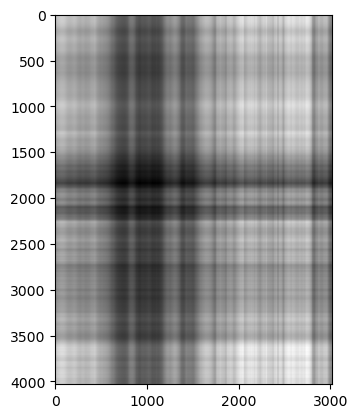

In [31]:
reconstimg = np.matrix(U[:, :1]) * np.diag(sigma[:1]) * np.matrix(V[:1, :])
_ = plt.imshow(reconstimg, cmap='gray')

In [32]:
reconstimg

matrix([[171.45580991, 171.46714193, 171.48183183, ..., 139.32645047,
         139.08936621, 138.98188355],
        [171.46564517, 171.47697784, 171.49166859, ..., 139.33444268,
         139.09734482, 138.989856  ],
        [171.48187128, 171.49320502, 171.50789716, ..., 139.34762816,
         139.11050786, 139.00300886],
        ...,
        [171.82537294, 171.83672938, 171.85145095, ..., 139.62676053,
         139.38916525, 139.28145092],
        [171.61356661, 171.62490905, 171.63961248, ..., 139.45464491,
         139.2173425 , 139.10976095],
        [171.53609987, 171.54743719, 171.56213398, ..., 139.39169477,
         139.15449949, 139.0469665 ]], shape=(4032, 3024))

In [1]:
import numpy as np

# Simulate some image data (e.g., grayscale pixel values)
# Let's create 5 images, each with 2 features (pixels)
data = np.array([
    [10, 20],
    [30, 40],
    [50, 60],
    [70, 80],
    [90, 100]
])

# 1. Calculate the Mean
mean_data = np.mean(data, axis=0)
print("Mean:", mean_data)

# 2. Center the Data (Subtract the mean)
centered_data = data - mean_data
print("Centered Data:\n", centered_data)

# 3. Calculate the Covariance Matrix
covariance_matrix = np.cov(centered_data, rowvar=False) # rowvar=False is crucial!
print("Covariance Matrix:\n", covariance_matrix)

# 4. Eigenvalue Decomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)

# 5. Sort Eigenvalues and Eigenvectors
# The eigenvectors are the principal components
eigenvalues = np.sort(eigenvalues)[::-1] # Sort in descending order
eigenvectors = eigenvectors[:, :] # Select all rows

print("Eigenvalues:\n", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

# 6. Select the Top K Principal Components
k = 2  # Let's take the top 2 principal components
selected_eigenvectors = eigenvectors[:, :k]
print("Selected Eigenvectors:\n", selected_eigenvectors)
# 7. Project the Data onto the Selected Components
projected_data = np.dot(centered_data, selected_eigenvectors)
print("Projected Data:\n", projected_data)

Mean: [50. 60.]
Centered Data:
 [[-40. -40.]
 [-20. -20.]
 [  0.   0.]
 [ 20.  20.]
 [ 40.  40.]]
Covariance Matrix:
 [[1000. 1000.]
 [1000. 1000.]]
Eigenvalues:
 [2000.    0.]
Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Selected Eigenvectors:
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
Projected Data:
 [[-56.56854249   0.        ]
 [-28.28427125   0.        ]
 [  0.           0.        ]
 [ 28.28427125   0.        ]
 [ 56.56854249   0.        ]]
